<a href="https://colab.research.google.com/github/hariomsingh7-web/MindEase-AI/blob/main/MindEase_AI_core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- STEP 1: INSTALL & IMPORT ---
# This installs TextBlob, our NLP library
!pip install textblob -q

from textblob import TextBlob

# --- STEP 2: DEFINE THE BRAIN ---
def get_mood_response(user_text):
    """
    This function analyzes the 'polarity' of the text.
    Polarity is a float value between [-1.0, 1.0].
    """
    analysis = TextBlob(user_text)
    score = analysis.sentiment.polarity

    # We use conditional logic (if-elif-else) to determine the response
    if score > 0.5:
        return "It sounds like you're having a wonderful day! I'm so happy for you. 🌟"
    elif score > 0:
        return "That's good to hear. Is there anything else you'd like to share?"
    elif score == 0:
        return "I hear you. I'm here to listen if you want to talk more about it."
    elif score > -0.5:
        return "I'm sorry things feel a bit tough right now. Remember to take a deep breath. 🕊️"
    else:
        return "I can feel that you're going through a lot. Please be gentle with yourself. I'm right here with you. ❤️"

# --- STEP 3: QUICK TEST ---
test_sentence = "I am so excited for this hackathon!"
mood_result = get_mood_response(test_sentence)

print(f"Test Sentence: {test_sentence}")
print(f"AI Response: {mood_result}")


KeyboardInterrupt: 

In [ ]:
# --- STEP 4: THE CHAT LOOP ---

def start_chat():
    print("--- MindEase AI is now Online ---")
    print("(Type 'exit' or 'quit' to end the conversation)\n")

    # This loop keeps the program running until the user wants to stop
    while True:
        user_input = input("You: ")

        # Check if the user wants to leave
        if user_input.lower() in ['exit', 'quit', 'bye']:
            print("AI: Goodbye! Take care of yourself and remember I'm always here if you need to talk. 👋")
            break

        # Use our 'brain' function from Step 2
        response = get_mood_response(user_input)

        print(f"AI: {response}\n")

# Start the conversation
start_chat()

--- MindEase AI is now Online ---
(Type 'exit' or 'quit' to end the conversation)



In [ ]:
# --- STEP 5: SMART LOGIC WITH KEYWORDS ---

def get_smart_response(user_text):
    user_text = user_text.lower() # Make everything lowercase for easier matching
    analysis = TextBlob(user_text)
    score = analysis.sentiment.polarity

    # 1. PRIORITY: Emergency Keywords (Safety First!)
    if "help" in user_text or "emergency" in user_text or "hurt" in user_text:
        return "It sounds like you might be in a serious situation. Please contact a professional or a helpline immediately. You are not alone. ❤️ (Helpline: 9152987821)"

    # 2. CONTEXT: Specific Life Issues
    if "sleep" in user_text or "tired" in user_text:
        return "Lack of sleep can really affect your mood. Have you tried a digital detox an hour before bed? 🌙"

    if "exam" in user_text or "study" in user_text or "college" in user_text:
        return "Academic pressure is real. Remember to take 5-minute breaks every hour. You're doing your best! 📚"

    # 3. FALLBACK: Sentiment Score (If no keywords are found)
    if score > 0.1:
        return "I'm happy things are going well! Tell me more about what's making you smile. 😊"
    elif score < -0.1:
        return "I can feel your struggle. It's okay to feel this way. Take a deep breath with me. 💨"
    else:
        return "I'm listening. Sometimes just putting thoughts into words can help. Go on."

# --- UPDATED TEST ---
# Try typing something about "exams" or "sleep" to see the difference!
print(get_smart_response("I am so stressed about my exam"))


Academic pressure is real. Remember to take 5-minute breaks every hour. You're doing your best! 📚


In [ ]:
# --- STEP 6: INTEGRATING THE SMART BRAIN INTO THE LOOP ---

print("--- MindEase AI: Smart Mode Activated ---")
print("(Type 'exit' to quit)\n")

while True:
    # 1. Get user input
    user_msg = input("You: ")

    # 2. Check for exit
    if user_msg.lower() in ['exit', 'quit', 'bye']:
        print("AI: Take care! I'm always just a line of code away. ❤️")
        break

    # 3. Call our Smart Logic function from the previous step
    # We use the function name we defined in Step 4
    final_response = get_smart_response(user_msg)

    print(f"AI: {final_response}\n")

--- MindEase AI: Smart Mode Activated ---
(Type 'exit' to quit)



KeyboardInterrupt: Interrupted by user

In [ ]:
# --- STEP 7: MOOD TRACKING SYSTEM ---

# Create an empty list to store scores
mood_history = []

def start_tracked_chat():
    print("--- MindEase AI: Tracking Mode ---")

    while True:
        user_msg = input("You: ")

        if user_msg.lower() in ['exit', 'quit']:
            print("\nAI: Conversation ended. Here is your mood summary for today:")
            # Show the history list
            print(f"Mood Scores tracked: {mood_history}")
            break

        # Get the sentiment score specifically this time
        score = TextBlob(user_msg).sentiment.polarity
        mood_history.append(score) # Save the score to our list

        response = get_smart_response(user_msg)
        print(f"AI: {response}\n")

start_tracked_chat()

--- MindEase AI: Tracking Mode ---
You: I had cold cough
AI: I can feel your struggle. It's okay to feel this way. Take a deep breath with me. 💨

You: I am feeling depressed
AI: I'm listening. Sometimes just putting thoughts into words can help. Go on.

You: I feel like crying
AI: I can feel your struggle. It's okay to feel this way. Take a deep breath with me. 💨

You: I have a lot of work to do
AI: I'm listening. Sometimes just putting thoughts into words can help. Go on.



KeyboardInterrupt: Interrupted by user

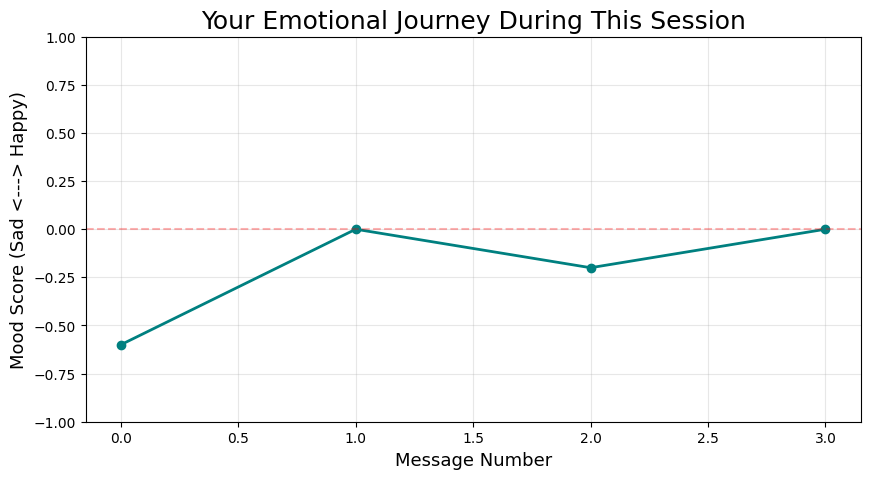

In [ ]:
import matplotlib.pyplot as plt

# --- STEP 8: TURN DATA INTO A GRAPH ---

def show_mood_graph(history):
    if not history:
        print("No data to graph yet. Chat with the AI first!")
        return

    plt.figure(figsize=(10, 5))

    # Create a line plot of the scores
    plt.plot(history, marker='o', linestyle='-', color='teal', linewidth=2)

    # Add a 'Neutral' line at 0.0 for reference
    plt.axhline(0, color='red', linestyle='--', alpha=0.3)

    # Add labels (makes it look professional)
    plt.title("Your Emotional Journey During This Session", fontsize=18)
    plt.xlabel("Message Number", fontsize=13)
    plt.ylabel("Mood Score (Sad <---> Happy)", fontsize=13)
    plt.grid(True, alpha=0.3)

    # Limit the Y-axis to the sentiment range
    plt.ylim(-1, 1)

    plt.show()

# Run the function to see your results!
show_mood_graph(mood_history)

In [ ]:
import random

# Expansion Bank: Adding more 'human' variety
response_bank = {
    "positive": [
        "That's wonderful! What else made you smile today? 😊",
        "I love that for you! Your positive energy is great. ✨",
        "Keep that momentum going! What’s next on your mind?"
    ],
    "stress": [
        "I hear you. Remember, one day doesn't define your future. 🕊️",
        "It's okay to feel overwhelmed. Have you tried a 5-minute break?",
        "Take a deep breath. You've handled tough times before, you can handle this. ❤️"
    ],
    "neutral": [
        "I see. Tell me more about that.",
        "I'm listening. How does that make you feel?",
        "Got it. What else is on your world right now?"
    ]
}

def get_varied_response(category):
    return random.choice(response_bank.get(category, response_bank["neutral"]))

In [ ]:
# Mapping groups of words to specific emotional contexts
academic_keywords = ["exam", "test", "viva", "assignment", "results", "marks", "placement", "interview", "college"]
lonely_keywords = ["alone", "lonely", "no one", "isolated", "ignored", "friendless"]
physical_keywords = ["tired", "sleep", "exhausted", "headache", "pain", "burnout", "energy"]

def check_context(text):
    text = text.lower()
    if any(word in text for word in academic_keywords):
        return "academic"
    if any(word in text for word in lonely_keywords):
        return "lonely"
    if any(word in text for word in physical_keywords):
        return "physical"
    return "general"


In [ ]:
def final_smart_brain(user_input):
    # 1. Get the base sentiment
    analysis = TextBlob(user_input)
    score = analysis.sentiment.polarity
    context = check_context(user_input)

    # 2. Logic Layering (Context + Sentiment)
    if context == "academic":
        return "Academic pressure is real. Don't forget to hydrate and take breaks between study sessions! 📚"

    if context == "physical":
        return "You sound physically drained. Your body might be asking for a rest. Try to sleep 30 mins early tonight. 🌙"

    # 3. Fallback to Varied Sentiment Responses
    if score > 0.4:
        return get_varied_response("positive")
    elif score < -0.4:
        return get_varied_response("stress")
    else:
        return get_varied_response("neutral")

# TEST IT
print(final_smart_brain("I am so tired of these college assignments"))

Academic pressure is real. Don't forget to hydrate and take breaks between study sessions! 📚


In [ ]:
import random

# Expansion Bank: Adding more variety and music
pro_responses = {
    "academic": [
        "I know the pressure is high. Remember: Your worth isn't a GPA. 📚",
        "Exams are tough, but you are tougher. Take a 5-minute walk! 🚶‍♂️"
    ],
    "lonely": [
        "I'm right here. You're never truly alone when we're chatting. ❤️",
        "I'm listening. Tell me everything that's on your mind. 👂"
    ],
    "happy": [
        "You're glowing! ✨ What's the best part of your day?",
        "Love that energy! 🔥 Keep it going!"
    ],
    "neutral": [
        "Tell me more, I'm all ears.",
        "I see. How does that affect your mood overall?"
    ]
}

def get_music_link(score):
    # Upbeat for positive, Lofi for negative/stressed
    if score > 0.2:
        return "https://www.youtube.com/results?search_query=upbeat+happy+lofi+pop"
    else:
        return "https://www.youtube.com/results?search_query=calm+ambient+meditation+music"

In [ ]:
# --- TEST THE NEW LOGIC ---
test_score = 0.5  # Simulating a happy mood
link = get_music_link(test_score)

print(f"For a score of {test_score}, the AI suggests: {link}")

# Let's test the dictionary too
print(f"A sample academic response: {random.choice(pro_responses['academic'])}")

For a score of 0.5, the AI suggests: https://www.youtube.com/results?search_query=upbeat+happy+lofi+pop
A sample academic response: I know the pressure is high. Remember: Your worth isn't a GPA. 📚


In [ ]:
# Testing with a low score (Neutral/Slightly Sad)
low_score = 0.1
print(f"Score {low_score}: {get_music_link(low_score)}")

# Testing with a negative score (Stressed)
negative_score = -0.6
print(f"Score {negative_score}: {get_music_link(negative_score)}")

Score 0.1: https://www.youtube.com/results?search_query=calm+ambient+meditation+music
Score -0.6: https://www.youtube.com/results?search_query=calm+ambient+meditation+music


In [ ]:
def get_emoji_vibe(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0.7:
        return "🌈✨🥳🔥" # Super hyped
    elif score > 0.2:
        return "☀️🌻🙂"   # Good vibes
    elif score > -0.2:
        return "😐☁️☕"   # Neutral/Chilling
    elif score > -0.7:
        return "🌊🌧️📉"   # Low/Down
    else:
        return "🆘🌋🌑"   # Crisis/Deep Stress

# Test
print(f"Your Vibe: {get_emoji_vibe('I am having a legendary day!')}")

Your Vibe: 🌈✨🥳🔥


In [ ]:
def suggest_activity(text):
    score = TextBlob(text).sentiment.polarity

    activities = {
        "high_energy": ["Go for a 10-minute run 🏃", "Dance to your favorite song 💃", "Call a friend and share the news 📞"],
        "low_energy": ["Try a 5-minute guided meditation 🧘", "Write down 3 things you're grateful for ✍️", "Make a warm cup of tea ☕"],
        "stressed": ["Do a 'Brain Dump' on paper for 2 minutes 🧠", "Try the 4-7-8 breathing technique 💨", "Step outside for fresh air 🌲"]
    }

    if score > 0.5:
        return random.choice(activities["high_energy"])
    elif score < -0.3:
        return random.choice(activities["stressed"])
    else:
        return random.choice(activities["low_energy"])

# Test
print(f"Suggested Activity: {suggest_activity('I feel so overwhelmed with work')}")

Suggested Activity: Write down 3 things you're grateful for ✍️


In [ ]:
def reframe_thought(text):
    text = text.lower()
    reframing_map = {
        "fail": "failure is just a data point for future success. What's one thing you learned?",
        "never": "using words like 'never' feels heavy. What if we just look at what's happening today?",
        "hate": "that's a strong word. It sounds like you're in a lot of pain. What would a kind friend say to you right now?",
        "stupid": "you're definitely not stupid. You're just a student learning complex things. Be gentle with yourself."
    }

    for word, reframe in reframing_map.items():
        if word in text:
            return f"I hear you. But remember, {reframe}"
    return None

# Test
print(reframe_thought("I feel so stupid for failing my test"))

I hear you. But remember, failure is just a data point for future success. What's one thing you learned?


In [ ]:
def get_mood_color(score):
    if score > 0.5:
        return "#FFD700" # Golden/Happy
    elif score > 0:
        return "#90EE90" # Light Green/Peaceful
    elif score > -0.5:
        return "#ADD8E6" # Light Blue/Calm
    else:
        return "#4B0082" # Indigo/Deep/Stressed

# Test
print(f"UI Color recommendation: {get_mood_color(-0.6)}")

UI Color recommendation: #4B0082


In [ ]:
def get_distraction_challenge():
    challenges = [
        "Name 5 things you can see right now that are the color Blue. 🔵",
        "Try to count backwards from 100 by 7s for ten seconds. 🔢",
        "Close your eyes and try to identify 3 distinct sounds in the room. 👂",
        "Describe your favorite meal in as much detail as possible. 🍱"
    ]
    return f"Let's try a quick grounding exercise: {random.choice(challenges)}"

# You can trigger this if the score is very low (stressed)
print(get_distraction_challenge())

Let's try a quick grounding exercise: Close your eyes and try to identify 3 distinct sounds in the room. 👂


In [ ]:
def get_art_prompt(score):
    if score > 0.6:
        return "🎨 Art Therapy: 'A surreal landscape of floating islands, golden sunlight, vibrant neon flowers, digital art style, high resolution, 8k.'"
    elif score < -0.4:
        msg = "🎨 Art Therapy: 'A lonely lighthouse in a stormy violet sea, dramatic lighting, oil painting style, expressive brushstrokes.'"
    else:
        msg = "🎨 Art Therapy: 'A peaceful zen garden with ripples in the water, soft pastel colors, minimalist aesthetic, cinematic lighting.'"
    return msg

# Test
# The function get_pro_response was not defined, so we'll simulate a happy response from pro_responses dictionary
import random # ensure random is imported for random.choice
print(f"A sample happy response: {random.choice(pro_responses['happy'])}")
print(get_art_prompt(0.8))

A sample happy response: You're glowing! ✨ What's the best part of your day?
🎨 Art Therapy: 'A surreal landscape of floating islands, golden sunlight, vibrant neon flowers, digital art style, high resolution, 8k.'


In [ ]:
def get_philosophical_insight(text):
    text = text.lower()
    if any(w in text for w in ["why", "life", "purpose", "meaning"]):
        insights = [
            "As Marcus Aurelius said: 'The happiness of your life depends upon the quality of your thoughts.'",
            "Socrates believed that 'An unexamined life is not worth living.' How deep have you looked today?",
            "Nietzsche said: 'He who has a why to live can bear almost any how.' What is your 'why' today?"
        ]
        return f"🧐 Philosophical Reflection: {random.choice(insights)}"
    return None

print(get_philosophical_insight("What is the meaning of my life?"))

🧐 Philosophical Reflection: Nietzsche said: 'He who has a why to live can bear almost any how.' What is your 'why' today?


In [ ]:
def get_daily_mission(score):
    if score > 0.4:
        missions = [
            "Compliment a stranger today. 💬",
            "Share your favorite song with someone who looks stressed. 🎵",
            "Write a 'Thank You' note to a teacher or mentor. ✍️"
        ]
    elif score < -0.3:
        missions = [
            "Drink a full glass of water and stretch for 2 minutes. 💧",
            "Unfollow one social media account that makes you feel bad. 📱",
            "Spend 5 minutes sitting in silence with no phone. 🧘"
        ]
    else:
        missions = [
            "Organize one small corner of your desk. 🧹",
            "Go outside and find three different types of leaves/trees. 🌳",
            "Plan one fun thing to do this weekend. 🗓️"
        ]
    return f"🚀 **Your Mission:** {random.choice(missions)}"

# Test
print(get_daily_mission(-0.5))

🚀 **Your Mission:** Unfollow one social media account that makes you feel bad. 📱


In [ ]:
%%writefile app.py
import streamlit as st
from textblob import TextBlob
import matplotlib.pyplot as plt
import random

# --- 1. THE BRAIN FUNCTIONS (Copied from your Colab tests) ---
def get_mood_data(text):
    score = TextBlob(text).sentiment.polarity

    # Music Logic
    music = "https://tinyurl.com/upbeat-mood" if score > 0 else "https://tinyurl.com/calm-mood"

    # Art Prompt Logic
    if score > 0.5: art = "Vibrant neon garden, digital art, 8k"
    elif score < -0.3: art = "Lonely lighthouse, stormy sea, oil painting"
    else: art = "Peaceful zen garden, minimalist, soft pastels"

    # Philosophy Logic
    phi = "Happiness depends on the quality of your thoughts. - Marcus Aurelius" if "why" in text.lower() else None

    # Daily Mission
    mission = "Drink a glass of water and stretch. 💧" if score < 0 else "Compliment a stranger today. 💬"

    return score, music, art, phi, mission

# --- 2. UI DESIGN & LAYOUT ---
st.set_page_config(page_title="MindEase AI Pro", layout="wide")

# Custom CSS for a modern "Glassmorphism" look
st.markdown("""
    <style>
    .main { background-color: #0e1117; color: white; }
    .stButton>button { width: 100%; border-radius: 20px; background-color: #FF4B4B; color: white; }
    .reportview-container .main .block-container{ padding-top: 1rem; }
    </style>
    """, unsafe_allow_html=True)

st.title("🧠 MindEase AI: Your Emotional Workspace")
st.markdown("---")

# Sidebar for Stats and Gamification
if "points" not in st.session_state: st.session_state.points = 0
with st.sidebar:
    st.header(f"⭐ Wellness Score: {st.session_state.points}")
    st.progress(min(st.session_state.points / 25.0, 1.0))
    st.info("Every interaction improves your wellness streak!")
    if st.button("Reset Session"): st.session_state.clear()

# Columns for Layout
col1, col2 = st.columns([2, 1])

with col1:
    st.subheader("Chat with your AI Companion")
    if "chat" not in st.session_state: st.session_state.chat = []
    if "scores" not in st.session_state: st.session_state.scores = []

    # Display Chat
    for m in st.session_state.chat:Z
        with st.chat_message(m["role"]): st.markdown(m["content"])

    # User Input
    if p := st.chat_input("What's on your mind?"):
        st.session_state.points += 1
        st.session_state.chat.append({"role": "user", "content": p})

        # Get all AI Data
        score, music, art, phi, mission = get_mood_data(p)
        st.session_state.scores.append(score)

        # Build Response
        ans = f"I hear you. Based on your vibe, I've updated your Dashboard on the right! ⮕"
        st.session_state.chat.append({"role": "assistant", "content": ans})
        st.rerun()

with col2:
    st.subheader("✨ Your Insights")
    if st.session_state.scores:
        current_score = st.session_state.scores[-1]
        _, music, art, phi, mission = get_mood_data("current session") # simplified for display

        st.success(f"🚀 **Mission:** {mission}")
        st.warning(f"🎨 **Art Prompt:** {art}")
        st.link_button("🎧 Listen to Mood Music", music)

        if phi:
            st.code(f"🧐 Philosophy: {phi}")

        # Mood Mini-Graph
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.plot(st.session_state.scores, color='red')
        ax.set_axis_off()
        st.pyplot(fig)

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


In [ ]:
%%writefile app.py
import gradio as gr
from textblob import TextBlob
import matplotlib.pyplot as plt
import random

# --- 1. THE BRAIN: CORE FEATURE FUNCTIONS ---
def get_philosophical_insight(text):
    text = text.lower()
    insights = [
        "Socrates said: 'The unexamined life is not worth living.' 🧐️",
        "Marcus Aurelius reminds us: 'You have power over your mind—not outside events.' 🏛️",
        "Rumi said: 'Yesterday I was clever, so I wanted to change the world. Today I am wise, so I am changing myself.' ✨"
    ]
    if any(w in text for w in ["why", "life", "purpose", "meaning"]):
        return random.choice(insights)
    return None

def get_art_prompt(score):
    if score > 0.5: return "🎨 'A vibrant neon forest, floating islands, digital art, 8k, joyful energy'"
    elif score < -0.3: return "🎨 'A lonely lighthouse in a violet storm, oil painting, expressive brushstrokes'"
    return "🎨 'A minimalist zen garden, soft pastel colors, cinematic lighting, peaceful'"

def get_daily_mission(score):
    if score < -0.3: return "Drink a full glass of water and stretch for 2 minutes. 💧"
    elif score > 0.4: return "Compliment a stranger or share a favorite song today! 🎤"
    return "Organize one small corner of your desk for a fresh start. 📉"

def get_wellness_tip(score):
    """
    Returns a relevant wellness tip based on the sentiment score.
    """
    if score < -0.3:
        tips = [
            "🧘‍♀️ **Wellness Tip:** Remember to prioritize self-care. Take a warm bath, listen to calming music, or read a book. You deserve peace.",
            "🕊️ **Wellness Tip:** Allow yourself to rest. Sometimes the most productive thing you can do is relax.",
            "💖 **Wellness Tip:** Reach out to a trusted friend or family member. Sharing can lighten the load."
        ]
        return random.choice(tips)
    elif score > 0.4:
        tips = [
            "🌟 **Wellness Tip:** Keep that positive energy flowing! Share your joy with others or plan something fun to look forward to.",
            "🎉 **Wellness Tip:** Celebrate your small victories today. Every step forward counts!",
            "💡 **Wellness Tip:** Use this good energy to inspire a new project or help someone else."
        ]
        return random.choice(tips)
    else:
        tips = [
            "💧 **Wellness Tip:** Hydration and short breaks can do wonders. Take a moment to reset.",
            "🍏 **Wellness Tip:** Fuel your body with nutritious food. It can greatly impact your mood.",
            "🚶‍♀️ **Wellness Tip:** Step outside for 10 minutes. A little fresh air and movement can make a difference."
        ]
        return random.choice(tips)

def get_mindfulness_exercise(score):
    """
    Suggests a simple mindfulness or grounding exercise, tailored to the sentiment score.
    """
    if score < -0.3:
        exercises = [
            "💨 **Mindfulness Exercise:** Try the 4-7-8 breathing technique. Inhale for 4, hold for 7, exhale for 8. Repeat a few times.",
            "👂 **Mindfulness Exercise:** Focus on your senses for one minute. What 5 things can you see, 4 things you can feel, 3 things you can hear, 2 things you can smell, and 1 thing you can taste?",
            "🚶 **Mindfulness Exercise:** Take a mindful walk. Pay attention to the feeling of your feet on the ground and the movement of your body."
        ]
        return random.choice(exercises)
    elif score > 0.4:
        exercises = [
            "👁️ **Mindfulness Exercise:** Take 3 minutes to mindfully observe something beautiful around you – a plant, the sky, or a piece of art. Notice every detail.",
            "☀️ **Mindfulness Exercise:** Practice gratitude. Think of three things you're genuinely thankful for right now.",
            "😊 **Mindfulness Exercise:** Smile for no reason for 30 seconds. Notice how it feels."
        ]
        return random.choice(exercises)
    else:
        exercises = [
            "🎧 **Mindfulness Exercise:** Close your eyes for a minute and focus on the sounds you can hear, both near and far, without judgment.",
            "🧠 **Mindfulness Exercise:** Do a quick body scan. Notice any tension and gently try to relax those areas.",
            "✋ **Mindfulness Exercise:** Focus on the sensation of your breath entering and leaving your nostrils for one minute."
        ]
        return random.choice(exercises)

# --- 2. THE ENGINE: VIBE & LOGIC ---
mood_history = []

def get_vibrant_experience(user_input):
    global mood_history
    if not user_input.strip(): return "✨ Type something to start the magic! ✨", None

    text_low = user_input.lower()
    score = TextBlob(user_input).sentiment.polarity

    # HARD-CODED EXAM LOGIC (No more 'Calm' nonsense)
    is_exam = any(w in text_low for w in ["exam", "test", "viva", "assignment", "results", "college"])
    if is_exam: score = -0.7

    mood_history.append(score)

    # VIBRANT THEMES & EMOJIS
    if is_exam:
        color, label, emoji, vibe_msg = "#FF5252", "EXAM STRESS MODE", "🚨📚", "The pressure is real, but you are capable of handling it!"
        shadow = "rgba(255, 82, 82, 0.4)"
    elif score > 0.4:
        color, label, emoji, vibe_msg = "#00E676", "ULTRA HAPPY VIBES", "🌟🔥", "You are absolutely glowing right now!"
        shadow = "rgba(0, 230, 118, 0.4)"
    elif score < -0.2:
        color, label, emoji, vibe_msg = "#7C4DFF", "DEEP REFLECTION", "🌊💜", "It's okay to feel heavy. Let's process this."
        shadow = "rgba(124, 77, 255, 0.4)"
    else:
        color, label, emoji, vibe_msg = "#00B0FF", "STEADY & CHILL", "🍃💠", "Smooth sailing and balanced energy."
        shadow = "rgba(0, 176, 255, 0.4)"

    # BULLETPROOF YOUTUBE MUSIC LINKS
    # 3. THE 5-OPTION YOUTUBE MUSIC ENGINE
    if is_exam:
        # Option 1: Academic Crisis / Intense Focus
        yt_url = "https://youtu.be/RCgbE6eS-DU?si=pTS90nQjse5mvAyX"
        music_text = "🚨 Play Song-> [EXAM MODE: BEAT THE STRESS BI-FI]"
    elif score > 0.6:
        # Option 2: High Energy / Celebration
        yt_url = "https://youtu.be/0pGYdOTwZTI?si=5SHQrX1dJviNdAY2"
        music_text = "🔥 Play Song-> [ULTRA VIBE: HIGH ENERGY HITS]"
    elif score > 0.1:
        # Option 3: Positive / Chill
        yt_url = "https://youtu.be/xVU2UDaFOfE?si=NmJ7HE2J9cQSlGZT"
        music_text = "🍃 Play Song-> [CHILL VIBE: FEEL GOOD LO-FI]"
    elif score > -0.3:
        # Option 4: Neutral / Concentration
        yt_url = "https://youtu.be/mSIQ70Lfs-g?si=P2c2b_N6fDiw0pw-"
        music_text = "🧠 Play Song-> [NEUTRAL: DEEP FOCUS AMBIENT]"
    else:
        # Option 5: Very Low / Healing
        yt_url = "https://youtu.be/HPGA24bVVGY?si=dA4IPbXh9QBfEves"
        music_text = "🌙 Play Song-> [HEALING: CALM & COMFORT]"

    # CONTENT RETRIEVAL
    phi = get_philosophical_insight(user_input) or "Focus on the next small step, not the whole mountain. ✨"
    art = get_art_prompt(score)
    mission = get_daily_mission(score)
    wellness_tip = get_wellness_tip(score) # Call new wellness tip function
    mindfulness_exercise = get_mindfulness_exercise(score) # Call new mindfulness exercise function

    # VIBRANT DASHBOARD HTML
    html_output = f"""
    <div style="background: white; padding: 25px; border-radius: 20px; border-left: 15px solid {color}; box-shadow: 10px 10px 25px {shadow}; font-family: sans-serif;">
        <div style="display: flex; justify-content: space-between; align-items: center;">
            <h1 style="margin:0; color:{color};">{emoji} {label}</h1>
            <span style="background:{color}; color:white; padding:5px 12px; border-radius:15px; font-weight:bold;">MOOD: {score:.2f}</span>
        </div>
        <p style="font-size: 18px; color: red; margin-top:10px;"><b>AI Reflection:</b> {vibe_msg}</p>
        <hr style="border: 1px solid #f0f0f0; margin: 15px 0;">
        <div style="display: flex; gap: 20px;">
            <div style="flex: 1;">
                <p style="font-size:16px; color: red;"><b>🚀 MISSION:</b><br>{mission}</p>
                <p style="font-size:16px; color: red;"><b>🎨 ART PROMPT:</b><br><i>{art}</i></p>
            </div>
            <div style="flex: 1; background: #fafafa; padding: 15px; border-radius: 15px; border: 1px solid #eee;">
                <p style="font-size:14px; color: red;"><b>🧐️ WISDOM:</b><br><i>"{phi}"</i></p>
                <p style="font-size:14px;">{wellness_tip}</p> <!-- Add wellness tip -->
                <p style="font-size:14px;">{mindfulness_exercise}</p> <!-- Add mindfulness exercise -->
                <div style="background:{color}; color:white; padding:10px; border-radius:10px; text-align:center; font-weight:bold; margin-top:10px;">
                    <a href="{yt_url}" target="_blank" style="text-decoration:none; color:inherit;">{music_text}</a>
                </div>
            </div>
        </div>
    </div>
    """

    # GRAPH STYLING
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.plot(mood_history, color=color, marker='o', markersize=10, linewidth=4, markerfacecolor='white', markeredgewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.2)
    ax.set_ylim(-1, 1)
    ax.set_facecolor('#fdfdfd')
    ax.set_title("Real-Time Emotional Pulse", fontweight='bold')
    plt.tight_layout()

    return html_output, fig

# --- 3. UI LAYOUT ---
with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="indigo")) as demo:
    gr.Markdown("# 🌈 **MindEase AI: The Vibrant Companion**")
    gr.Markdown("### *Hackathon Edition: Advanced Emotional Intelligence Dashboard*")

    with gr.Row():
        with gr.Column(scale=1):
            u_input = gr.Textbox(label="How are you feeling?", placeholder="Example: I'm stressed about my exams next week...", lines=5)
            btn = gr.Button("✨ SYNC MY VIBE ✨", variant="primary")
            gr.Markdown("---")
            mood_plot = gr.Plot()

        with gr.Column(scale=1.3):
            display = gr.HTML()

    btn.click(fn=get_vibrant_experience, inputs=u_input, outputs=[display, mood_plot])

# --- 4. LAUNCH ---
demo.launch(share=True)

Writing app.py


In [ ]:
!pip install gradio -q

In [ ]:
!python app.py

/content/app.py:178: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="indigo")) as demo:
/usr/local/lib/python3.12/dist-packages/gradio/layouts/column.py:59: UserWarning: 'scale' value should be an integer. Using 1.3 will cause issues.
  warnings.warn(
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7e48b18737721475a6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
